In [110]:
#Imports 
import rasterio
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from lightgbm import LGBMClassifier

## Importing data:

In [111]:
back = rasterio.open("/kaggle/input/competitions/geohab-mlwg-competition-2026/MBES/backscatter.tif")
bath = rasterio.open("/kaggle/input/competitions/geohab-mlwg-competition-2026/MBES/bathymetry.tif")
train_df = pd.read_csv('/kaggle/input/competitions/geohab-mlwg-competition-2026/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/geohab-mlwg-competition-2026/test.csv')

In [112]:
print('Train set: ', train_df.shape)
display(train_df.head())

print('Test set: ', test_df.shape)
display(test_df.head())

back_data = back.read(1)
print('Backscatter data: ',back_data.shape)
print(back_data[:5, :5])

bath_data = bath.read(1)
print('Bathymestry data: ', bath_data.shape)
print(bath_data[:5, :5])

Train set:  (6256, 3)


,class,x,y
0,NVB,453594.477237,5.679192e+06
1,FMAT,453561.906453,5.679109e+06
2,ALG,453744.452238,5.679033e+06
3,ALG,453863.445302,5.679038e+06
4,ALG,453964.611906,5.679017e+06


Test set:  (98, 3)


,ID,x,y
0,1,453702.166779,5.679044e+06
1,2,454126.252800,5.678999e+06
2,3,453957.881092,5.678942e+06
3,4,453798.917484,5.678955e+06
4,5,453520.953671,5.679124e+06


Backscatter data:  (4040, 4743)
[[-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]]
Bathymestry data:  (4040, 4743)
[[-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]]


## Extracting Features:

### Grid feature

In [113]:
def get_neighborhood_features(x, y):
    row, col = bath.index(x, y)
    
    features = []
    
    for dr in [-10, 0, 10]:
        for dc in [-10, 0, 10]:
            r = row + dr
            c = col + dc
            
            try:
                depth = bath_data[r, c]
                scatter = back_data[r, c]
            except:
                depth = 0
                scatter = 0
            
            features.append(depth)
            features.append(scatter)
    
    return features

In [114]:
features = train_df.apply(
    lambda r: get_neighborhood_features(r['x'], r['y']),
    axis=1
)

train_feature_cols = [f'f{i}' for i in range(len(features.iloc[0]))]

train_df[train_feature_cols] = pd.DataFrame(features.tolist(), index=train_df.index)

In [115]:
print(train_feature_cols)

['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17']


In [116]:
train_df.head()

,class,x,y,f0,f1,f2,f3,f4,f5,f6,...,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17
0,NVB,453594.477237,5.679192e+06,-10000.000000,-10000.000000,-10000.000000,-10000.000000,-10000.000000,-10000.000000,-2.701910,...,-2.822883,-18.669088,-3.042680,-17.409285,-3.071986,-19.609058,-3.214768,-17.089449,-3.226695,-20.558794
1,FMAT,453561.906453,5.679109e+06,-5.822679,-20.558794,-5.684667,-19.609058,-5.565738,-19.928892,-5.839717,...,-5.668992,-20.558794,-5.728967,-21.819818,-5.970913,-24.649494,-5.963757,-18.669088,-5.685689,-19.609058
2,ALG,453744.452238,5.679033e+06,-9.098838,-24.019592,-8.643910,-24.019592,-8.590751,-24.649494,-9.605904,...,-9.288988,-23.389690,-9.254910,-23.389690,-9.791964,-20.868862,-9.806957,-18.979156,-10.076847,-23.079622
3,ALG,453863.445302,5.679038e+06,-6.771722,-24.019592,-6.573735,-24.019592,-6.601678,-22.759789,-7.335696,...,-7.263793,-21.189917,-7.043997,-22.759789,-8.027799,-22.129887,-7.774948,-21.499985,-7.688733,-18.979156
4,ALG,453964.611906,5.679017e+06,-8.983999,-23.709524,-8.138379,-27.799006,-8.888924,-24.019592,-9.603859,...,-9.784807,-22.449720,-9.222878,-27.169104,-10.735896,-29.689932,-10.166810,-25.599232,-10.554947,-29.379864


### Advanced feature engineering:

In [117]:
import numpy as np

def get_advanced_features(x, y):
    row, col = bath.index(x, y)
    
    depths = []
    scatters = []
    
    for dr in [-1, 0, 1]:
        for dc in [-1, 0, 1]:
            r = row + dr
            c = col + dc
            
            if 0 <= r < bath_data.shape[0] and 0 <= c < bath_data.shape[1]:
                depths.append(bath_data[r, c])
                scatters.append(back_data[r, c])
            else:
                depths.append(0)
                scatters.append(0)
    
    return [
        np.mean(depths),
        np.std(depths),
        np.min(depths),
        np.max(depths),
        np.mean(scatters),
        np.std(scatters),
        np.min(scatters),
        np.max(scatters),
    ]

In [118]:
features = train_df.apply(
    lambda r: get_advanced_features(r['x'], r['y']),
    axis=1
)

adv_feature_cols = [
    'depth_mean', 'depth_std', 'depth_min', 'depth_max',
    'scatter_mean', 'scatter_std', 'scatter_min', 'scatter_max'
]

train_df[adv_feature_cols] = pd.DataFrame(features.tolist(), index=train_df.index)

In [119]:
print(adv_feature_cols)

['depth_mean', 'depth_std', 'depth_min', 'depth_max', 'scatter_mean', 'scatter_std', 'scatter_min', 'scatter_max']


## Model:

In [120]:
target = 'class'

X = train_df[train_feature_cols + adv_feature_cols]
y = train_df[target].map({'SGAM': 0, 'NVB': 1, 'SGZ': 2, 'ALG': 3, 'FMAT': 4})

#splitting the data into train/val splits
X_train , X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=24)

In [121]:
model = LGBMClassifier(random_state=42)
model.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001682 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4592
[LightGBM] [Info] Number of data points in the train set: 5004, number of used features: 26
[LightGBM] [Info] Start training from score -3.605338
[LightGBM] [Info] Start training from score -0.723170
[LightGBM] [Info] Start training from score -2.027269
[LightGBM] [Info] Start training from score -2.215374
[LightGBM] [Info] Start training from score -1.399167
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(random_state=42)

In [122]:
val_preds = model.predict(X_val)
val_acc = accuracy_score(y_val, val_preds)
val_f1 = f1_score(y_val, val_preds, average='weighted')

print('Validation accuracy LGBM: ', val_acc)
print('Validation f1 LGBM: ', val_f1)

Validation accuracy LGBM:  0.9121405750798722
Validation f1 LGBM:  0.9115942382797164


## Feature Importance

In [123]:
import lightgbm as lgbm
import matplotlib.pyplot as plt

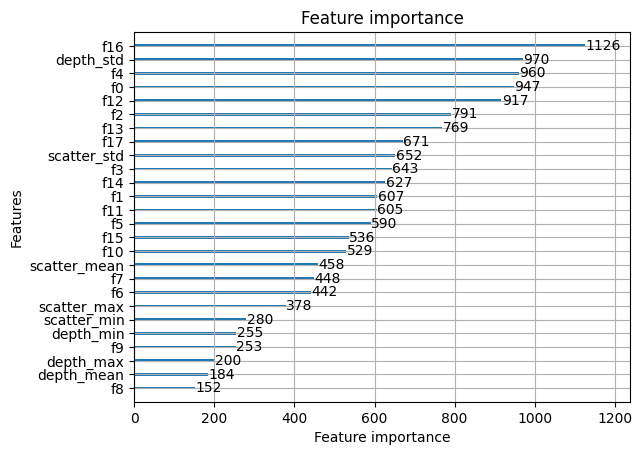

In [124]:
lgbm.plot_importance(model, max_num_features=30)
plt.show()

## Test preds

In [125]:
features = test_df.apply(
    lambda r: get_neighborhood_features(r['x'], r['y']),
    axis=1
)

test_feature_cols = [f'f{i}' for i in range(len(features.iloc[0]))]

test_df[test_feature_cols] = pd.DataFrame(features.tolist(), index=test_df.index)

In [126]:
features = test_df.apply(
    lambda r: get_advanced_features(r['x'], r['y']),
    axis=1
)

test_df[adv_feature_cols] = pd.DataFrame(features.tolist(), index=test_df.index)

In [127]:
X_test = test_df[test_feature_cols + adv_feature_cols]
y_preds = model.predict(X_test)

submission = pd.DataFrame({
    'ID': test_df['ID'],
    target: y_preds
})

submission[target] = submission[target].map({0: 'SGAM', 1: 'NVB', 2: 'SGZ', 3: 'ALG', 4: 'FMAT'})

submission.to_csv('submission.csv', index=False)